In [22]:
#!/usr/bin/env python3
# train_FG_long_k.py
# Convert wide (ETA, F1..F12, G1..G12) -> long dataset with mapping k->(Ri,M)
# Train NN to predict (Fval,Gval) from inputs (Ri, M, Eta, k).
# Optional: you can later extend pde_residuals(...) and set USE_PDE=True for PINN.

import os, time, json
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from sklearn.model_selection import train_test_split

# ---------------- User settings ----------------
DATA_PATH = "Grad-6-Merged.csv"   # your CSV
OUT_DIR = "pinn_fg_long_out_3"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# mapping k -> (Ri,M) as you described
pi_map = { 1: (1), 2: (2), 3: (3), 4: (4),  5: (5) }

# training hyperparams (tune)
SEED = 42
N_EPOCHS = 1600
BATCH_SIZE = 128
LR = 2e-3
ONECYCLE_MAX_LR = 8e-3
GRAD_CLIP = 5.0
LBFGS_ITERS = 200
EARLY_STOPPING_PATIENCE = 300
PRINT_EVERY = 80

USE_PDE = False   # set True only after you implement pde_residuals()
# ------------------------------------------------

os.makedirs(OUT_DIR, exist_ok=True)
np.random.seed(SEED); torch.manual_seed(SEED)

# ---------------- Load CSV and build long dataset ----------------
df_w = pd.read_csv(DATA_PATH)
print("Loaded CSV:", DATA_PATH, "shape:", df_w.shape)
print("Columns:", df_w.columns.tolist()[:20])

# find ETA column
eta_col = next((c for c in df_w.columns if c.strip().lower()=='eta' or 'eta' in c.lower()), None)
if eta_col is None:
    raise RuntimeError("ETA column not found in CSV.")

# check F/G columns exist
Pi_cols = [f"Pi{i}" for i in range(1,6)]
#G_cols = [f"G{i}" for i in range(1,13)]
for c in Pi_cols:
    if c not in df_w.columns:
        raise RuntimeError(f"Column {c} not found in CSV.")

# Build long records: for each k create rows with assigned Ri,M
records = []
n_eta = df_w.shape[0]
for k in range(1,6):
    re = pi_map[k]
    pi_col = f"Pi{k}"
    for i in range(n_eta):
        records.append({
            "Re": re,
            "Eta": float(df_w.iloc[i][eta_col]),
            #"k": float(k),           # include k as numeric (we'll normalize)
            "Pi_val": float(df_w.iloc[i][pi_col]),
            #"Gval": float(df_w.iloc[i][Gcol])
        })
df = pd.DataFrame.from_records(records)
print("Built long dataframe shape:", df.shape)
df.to_csv(os.path.join(OUT_DIR,"Cf_long_raw.csv"), index=False)



Loaded CSV: Grad-6-Merged.csv shape: (402, 6)
Columns: ['ETA', 'Pi1', 'Pi2', 'Pi3', 'Pi4', 'Pi5']
Built long dataframe shape: (2010, 3)


In [23]:
# ---------------- Attention-based model (replace previous broken MHA usage) ----------------
import os, time, json
import numpy as np
import torch, torch.nn as nn, torch.optim as optim
from sklearn.model_selection import train_test_split

# ---------- fallback defaults (only used if not defined earlier) ----------
try:
    DEVICE
except NameError:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
try:
    OUT_DIR
except NameError:
    OUT_DIR = "pinn_fg_long_out_attn"
os.makedirs(OUT_DIR, exist_ok=True)

SEED = globals().get("SEED", 42)
N_EPOCHS = globals().get("N_EPOCHS", 1600)
BATCH_SIZE = globals().get("BATCH_SIZE", 128)
LR = globals().get("LR", 2e-3)
ONECYCLE_MAX_LR = globals().get("ONECYCLE_MAX_LR", 8e-3)
GRAD_CLIP = globals().get("GRAD_CLIP", 5.0)
LBFGS_ITERS = globals().get("LBFGS_ITERS", 200)
EARLY_STOPPING_PATIENCE = globals().get("EARLY_STOPPING_PATIENCE", 300)
PRINT_EVERY = globals().get("PRINT_EVERY", 80)

torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ---------------- Prepare model inputs/outputs (rebuild to be self-contained) ----------------
# expects df with columns Ri,M,Eta,k,Cf_val
assert all(c in df.columns for c in ["Re","Eta","Pi_val"]), "df must contain Re, Eta, Pi_val"

X = df[["Re","Eta"]].values.astype(np.float32)
Y = df[["Pi_val"]].values.astype(np.float32)

# Normalize inputs and target per-column
X_mean = X.mean(axis=0); X_std = X.std(axis=0) + 1e-12
Y_mean = Y.mean(axis=0); Y_std = Y.std(axis=0) + 1e-12
Xn = (X - X_mean)/X_std
Yn = (Y - Y_mean)/Y_std

# train/val/test split stratified by Ri_M combos
df["combo"] = df["Re"].astype(str)
idxs = np.arange(Xn.shape[0])
train_idx, test_idx = train_test_split(idxs, test_size=0.18, random_state=SEED, stratify=df['combo'])
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, random_state=SEED, stratify=df['combo'].iloc[test_idx])

X_train = Xn[train_idx]; Y_train = Yn[train_idx]
X_val   = Xn[val_idx];   Y_val   = Yn[val_idx]
X_all   = Xn.copy()

print("Train/Val/Test sizes:", X_train.shape[0], X_val.shape[0], Xn.shape[0]-X_train.shape[0]-X_val.shape[0])

# convert to torch tensors
device = DEVICE
X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32, device=device)
X_val_t   = torch.tensor(X_val, dtype=torch.float32, device=device)
Y_val_t   = torch.tensor(Y_val, dtype=torch.float32, device=device)
X_all_t   = torch.tensor(X_all, dtype=torch.float32, device=device)
Yn_t      = torch.tensor(Yn, dtype=torch.float32, device=device)

Train/Val/Test sizes: 1648 181 181


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# ---------------- Attention model components (fixed) ----------------
class Tokenizer(nn.Module):
    """Project selected scalar inputs into seq_len token embeddings (N, seq_len, token_dim).
       This tokenizer matches the original intent: we only embed Re and Eta (seq_len=2).
    """
    def __init__(self, token_dim=64, seq_len=2):
        super().__init__()
        self.seq_len = seq_len
        self.embed_Re  = nn.Linear(1, token_dim)
        self.embed_Eta = nn.Linear(1, token_dim)
        self.act = nn.SiLU()
    def forward(self, x):
        # x: (N, D) where D must be >= 3 if you use indices 0 and 2
        # order expected: [Ri, M, Eta, k] but we only use Ri and Eta here.
        if x.size(1) < 2:
            raise RuntimeError(f"Tokenizer expected input with at least 2 columns but got {x.size(1)}")
        re  = self.act(self.embed_Re(x[:,0:1]))     # (N, token_dim)
        Eta = self.act(self.embed_Eta(x[:,1:2]))    # (N, token_dim)
        tokens = torch.stack([re, Eta], dim=1)      # (N, 2, token_dim)
        return tokens

class AttentionBlock(nn.Module):
    """Single attention block with residual and FFN"""
    def __init__(self, token_dim=64, num_heads=4, ff_mult=4, dropout=0.0):
        super().__init__()
        self.mha = nn.MultiheadAttention(embed_dim=token_dim, num_heads=num_heads, batch_first=True)
        self.ln1 = nn.LayerNorm(token_dim)
        self.ff = nn.Sequential(
            nn.Linear(token_dim, token_dim*ff_mult),
            nn.SiLU(),
            nn.Linear(token_dim*ff_mult, token_dim)
        )
        self.ln2 = nn.LayerNorm(token_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, tokens):
        # tokens: (N, seq_len, token_dim)
        attn_out, _ = self.mha(tokens, tokens, tokens)   # (N, seq_len, token_dim)
        x = self.ln1(tokens + self.dropout(attn_out))
        ff_out = self.ff(x)
        out = self.ln2(x + self.dropout(ff_out))
        return out

class AttentionPINN(nn.Module):
    def __init__(self, token_dim=64, num_heads=4, n_blocks=3, out_dim=1, seq_len=2):
        super().__init__()
        self.seq_len = seq_len
        self.token_dim = token_dim
        self.tokenizer = Tokenizer(token_dim=token_dim, seq_len=seq_len)
        # pos_emb must match seq_len
        self.pos_emb = nn.Parameter(torch.randn(1, seq_len, token_dim) * 0.01)
        self.blocks = nn.ModuleList([AttentionBlock(token_dim=token_dim, num_heads=num_heads) for _ in range(n_blocks)])
        # pooling + head: input dim = seq_len * token_dim
        self.pool = nn.Sequential(
            nn.Flatten(),                      # (N, seq_len*token_dim)
            nn.Linear(seq_len * token_dim, token_dim),
            nn.SiLU(),
            nn.Linear(token_dim, out_dim)
        )
        # init
        for p in self.modules():
            if isinstance(p, nn.Linear):
                nn.init.xavier_uniform_(p.weight)
                if p.bias is not None:
                    nn.init.zeros_(p.bias)

    def forward(self, x):
        # x: (N, D). Tokenizer will validate D.
        tokens = self.tokenizer(x) + self.pos_emb   # (N, seq_len, token_dim)
        for blk in self.blocks:
            tokens = blk(tokens)
        out = self.pool(tokens)   # (N, out_dim)
        return out

# ---------------- Instantiate model ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AttentionPINN(token_dim=64, num_heads=4, n_blocks=3, out_dim=1, seq_len=2).to(device)
print("Model params:", sum(p.numel() for p in model.parameters()))


Model params: 158657


In [25]:
# ---------------- Optimizer + Scheduler ----------------
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-6)
steps_per_epoch = max(1, int(np.ceil(X_train.shape[0] / float(BATCH_SIZE))))
total_steps = N_EPOCHS * steps_per_epoch
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=ONECYCLE_MAX_LR,
                                          total_steps=total_steps, pct_start=0.1, div_factor=10.0)
mse = nn.MSELoss()

# ---------------- Training loop ----------------
best_val = 1e12; patience = 0
history = {'train':[], 'val':[]}
t0 = time.time()
for ep in range(1, N_EPOCHS+1):
    model.train()
    perm = np.random.permutation(X_train.shape[0])
    losses = []
    for i in range(0, X_train.shape[0], BATCH_SIZE):
        idxb = perm[i:i+BATCH_SIZE]
        xb = torch.tensor(X_train[idxb], dtype=torch.float32, device=device)
        yb = torch.tensor(Y_train[idxb], dtype=torch.float32, device=device)
        optimizer.zero_grad()
        pred = model(xb)                     # (batch,1)
        loss = mse(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        try:
            scheduler.step()
        except Exception:
            pass
        losses.append(loss.item())
    train_loss = float(np.mean(losses))

    model.eval()
    with torch.no_grad():
        val_pred = model(torch.tensor(X_val, dtype=torch.float32, device=device))
        val_loss = float(mse(val_pred, torch.tensor(Y_val, dtype=torch.float32, device=device)).item())

    history['train'].append(train_loss); history['val'].append(val_loss)
    if ep % PRINT_EVERY == 0 or ep==1:
        print(f"Epoch {ep}/{N_EPOCHS}  train={train_loss:.3e} val={val_loss:.3e} lr={optimizer.param_groups[0]['lr']:.2e}")
    if val_loss < best_val:
        best_val = val_loss; patience = 0
        torch.save(model.state_dict(), os.path.join(OUT_DIR, "best_attn.pt"))
    else:
        patience += 1
        if patience > EARLY_STOPPING_PATIENCE:
            print("Early stopping at epoch", ep); break

t1 = time.time()
print("Training finished in {:.1f}s best_val={:.4e}".format(t1-t0, best_val))
# load best
model.load_state_dict(torch.load(os.path.join(OUT_DIR,"best_attn.pt"), map_location=device))
model.eval()

# ---------------- LBFGS refinement (optional) ----------------
print("LBFGS refine (optional)...")
try:
    lbfgs = optim.LBFGS(model.parameters(), max_iter=LBFGS_ITERS)
    def closure():
        lbfgs.zero_grad()
        pred = model(X_all_t)
        loss = mse(pred, Yn_t)
        loss.backward()
        return loss
    lbfgs.step(closure)
except Exception as e:
    print("LBFGS skipped/failed:", e)

# ---------------- Predict back to original scale ----------------
with torch.no_grad():
    Ypred_n = model(X_all_t).cpu().numpy()   # normalized predictions
Ypred = Ypred_n * Y_std + Y_mean            # invert normalization (original scale)

# attach predictions to df and save
df['p_Pi_val'] = Ypred[:,0]
out_csv = os.path.join(OUT_DIR, "Pi_long_preds_attn.csv")
df.to_csv(out_csv, index=False)
print("Saved long-format predictions to:", out_csv)

# save training history and norm params
np.savez(os.path.join(OUT_DIR,"norm_params_attn.npz"), X_mean=X_mean, X_std=X_std, Y_mean=Y_mean, Y_std=Y_std)
with open(os.path.join(OUT_DIR,"history_attn.json"), "w") as f:
    json.dump(history, f)

print("Done. Results saved in:", OUT_DIR)


Epoch 1/1600  train=1.454e+00 val=1.049e+00 lr=8.01e-04
Epoch 80/1600  train=8.577e-01 val=7.639e-01 lr=4.40e-03
Epoch 160/1600  train=1.004e+00 val=9.412e-01 lr=8.00e-03
Epoch 240/1600  train=1.008e+00 val=9.484e-01 lr=7.94e-03
Epoch 320/1600  train=1.007e+00 val=9.472e-01 lr=7.76e-03
Early stopping at epoch 365
Training finished in 179.3s best_val=6.9229e-01
LBFGS refine (optional)...
Saved long-format predictions to: pinn_fg_long_out_3\Pi_long_preds_attn.csv
Done. Results saved in: pinn_fg_long_out_3


In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- sanity checks ---
required = ['p_Pi_val', 'Pi_val']
for c in required:
    if c not in df.columns:
        raise RuntimeError(f"DataFrame must contain column '{c}'")

# create OUT_DIR if missing
os.makedirs(OUT_DIR, exist_ok=True)

# squared error column
df['err_Pi2'] = (df['p_Pi_val'] - df['Pi_val'])**2

# overall RMSE
rmse_overall = float(np.sqrt(df['err_Pi2'].mean()))
print("Overall RMSE (Pi):", rmse_overall)

# group by Re if present, otherwise single group 'all'
if 'Re' in df.columns:
    df['Re_str'] = df['Re'].astype(str)  # safe label for filenames
    group_col = 'Re_str'
    print("Grouping by 'Re'.")
else:
    df['Re_str'] = 'all'
    group_col = 'Re_str'
    print("No 'Re' column found — using single group 'all'.")

# RMSE per Re
rmse_Re = df.groupby(group_col).apply(lambda g: float(np.sqrt(g['err_Pi2'].mean())))
rmse_Re_df = rmse_Re.reset_index()
rmse_Re_df.columns = ['Re', 'rmse_Pi']
out_re_csv = os.path.join(OUT_DIR, "rmse_per_Re.csv")
rmse_Re_df.to_csv(out_re_csv, index=False)
print("Saved rmse_per_Re.csv ->", out_re_csv)

# plots: curves per Re (use 'Eta' if present)
x_col = 'Eta' if 'Eta' in df.columns else None
if x_col is None:
    print("No 'Eta' column found — plotting curves vs index within group.")

for re_label, g in df.groupby(group_col):
    sub = g.copy()
    if x_col is not None:
        try:
            sub = sub.sort_values(x_col)
            x = sub[x_col].values
            xlabel = x_col
        except Exception:
            x = np.arange(len(sub))
            xlabel = "index"
    else:
        x = np.arange(len(sub))
        xlabel = "index"

    y_true = sub['Pi_val'].values
    y_pred = sub['p_Pi_val'].values

    plt.figure(figsize=(8,4))
    plt.plot(x, y_true, '-', label='Pi true')
    plt.plot(x, y_pred, '--', label='Pi pred')
    plt.xlabel(xlabel)
    plt.ylabel('Pi')
    plt.legend()
    plt.title(f"Re={re_label}")
    plt.tight_layout()

    fname = os.path.join(OUT_DIR, f"curve_Re_{str(re_label).replace('/', '_')}.png")
    plt.savefig(fname)
    plt.close()

print("Saved curve plots in", OUT_DIR)

# parity scatter (all data) with overall RMSE annotation
plt.figure(figsize=(6,6))
plt.scatter(df['Pi_val'], df['p_Pi_val'], s=8)
mn = min(df['Pi_val'].min(), df['p_Pi_val'].min())
mx = max(df['Pi_val'].max(), df['p_Pi_val'].max())
plt.plot([mn,mx],[mn,mx], linestyle='--')
plt.xlabel("Pi true")
plt.ylabel("Pi pred")
plt.title(f"Parity: Pi pred vs true (RMSE={rmse_overall:.4e})")
plt.tight_layout()
par_fname = os.path.join(OUT_DIR, "parity_Pi.png")
plt.savefig(par_fname)
plt.close()
print("Saved parity plot ->", par_fname)

# print top/bottom Re by RMSE
top_bad = rmse_Re_df.sort_values('rmse_Pi', ascending=False).head(10)
top_good = rmse_Re_df.sort_values('rmse_Pi', ascending=True).head(10)
print("\nTop 10 worst Re by RMSE:\n", top_bad.to_string(index=False))
print("\nTop 10 best Re by RMSE:\n", top_good.to_string(index=False))


Overall RMSE (Pi): nan
Grouping by 'Re'.
Saved rmse_per_Re.csv -> pinn_fg_long_out_3\rmse_per_Re.csv


C:\Users\admin\AppData\Local\Temp\ipykernel_19172\2415912487.py:33: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



Saved curve plots in pinn_fg_long_out_3
Saved parity plot -> pinn_fg_long_out_3\parity_Pi.png

Top 10 worst Re by RMSE:
 Re  rmse_Pi
 1      NaN
 2      NaN
 3      NaN
 4      NaN
 5      NaN

Top 10 best Re by RMSE:
 Re  rmse_Pi
 1      NaN
 2      NaN
 3      NaN
 4      NaN
 5      NaN


In [34]:
# Modified plotting + RMSE script for uploaded dataset
# Reads: /mnt/data/Grad-6-Merged.csv
# Produces:
#  - interactive curve plot per Re: OUT_DIR/Pi_pred_vs_true_by_Re.html
#  - interactive parity plot: OUT_DIR/parity_Pi_plotly.html
#  - CSV with RMSE per Re: OUT_DIR/rmse_per_Re.csv

import os
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# ---------------- USER SETTINGS ----------------
IN_PATH = "Grad-6-Merged.csv"   # uploaded file
OUT_DIR = "out_plots"                     # output folder (will be created)
os.makedirs(OUT_DIR, exist_ok=True)

# ---------------- Load dataset ----------------
df = pd.read_csv(IN_PATH)
print("Loaded:", IN_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

# ---------------- Detect prediction and target columns ----------------
# Prefer explicit names used earlier: 'p_Pi_val' and 'Pi_val'
pred_candidates = [c for c in df.columns if c.startswith("p_")]
target_candidates = [c for c in df.columns if c.endswith("_val") and not c.startswith("p_")]

pred_col = None
target_col = None

if "p_Pi_val" in df.columns:
    pred_col = "p_Pi_val"
elif "p_Cf_val" in df.columns:
    pred_col = "p_Cf_val"
elif len(pred_candidates) > 0:
    pred_col = pred_candidates[0]

# choose Pi_val preferentially
if "Pi_val" in df.columns:
    target_col = "Pi_val"
elif "Cf_val" in df.columns:
    target_col = "Cf_val"
elif len(target_candidates) > 0:
    target_col = target_candidates[0]

if pred_col is None or target_col is None:
    raise RuntimeError(f"Could not detect prediction/target columns. Found preds: {pred_candidates}, targets: {target_candidates}")

print(f"Using prediction column: {pred_col}")
print(f"Using target column:     {target_col}")

# ---------------- Ensure 'Re' exists; if not, create single group 'all' ----------------
if "Re" not in df.columns:
    print("Column 'Re' not found — creating single-group label 'all'.")
    df["Re"] = "all"

# Optional: ensure 'Eta' exists for x-axis; if missing, we'll use index
has_eta = "Eta" in df.columns
if not has_eta:
    print("Column 'Eta' not present — plots will use group index on x-axis.")

# ---------------- Compute RMSE overall and per Re ----------------
df["err_sq"] = (df[pred_col] - df[target_col]) ** 2
rmse_overall = float(np.sqrt(df["err_sq"].mean()))
print(f"Overall RMSE ({target_col}): {rmse_overall:.6e}")

rmse_Re = df.groupby("Re").apply(lambda g: float(np.sqrt(g["err_sq"].mean())))
rmse_Re_df = rmse_Re.reset_index()
rmse_Re_df.columns = ["Re", "rmse"]
rmse_out_csv = os.path.join(OUT_DIR, "rmse_per_Re.csv")
rmse_Re_df.to_csv(rmse_out_csv, index=False)
print("Saved RMSE per Re ->", rmse_out_csv)
display(rmse_Re_df.sort_values("rmse").head(10))

# ---------------- Interactive curve plot (Plotly) ----------------
fig = go.Figure()
for re_val in sorted(df["Re"].unique(), key=lambda x: str(x)):
    sub = df[df["Re"] == re_val].copy()
    if has_eta:
        sub = sub.sort_values("Eta")
        x = sub["Eta"]
        x_label = "Eta"
    else:
        x = sub.index
        x_label = "index"

    # predicted
    fig.add_trace(go.Scatter(
        x=x, y=sub[pred_col],
        mode="lines",
        name=f"{pred_col} (Re={re_val})",
        hovertemplate=f"Re={re_val}<br>%{{x}}<br>{pred_col}=%{{y:.6e}}<extra></extra>"
    ))

    # true (dashed)
    fig.add_trace(go.Scatter(
        x=x, y=sub[target_col],
        mode="lines",
        name=f"{target_col} (Re={re_val})",
        line=dict(dash="dash"),
        hovertemplate=f"Re={re_val}<br>%{{x}}<br>{target_col}=%{{y:.6e}}<extra></extra>"
    ))

fig.update_layout(
    title=f"{target_col} true and predicted vs {x_label} (grouped by Re)",
    xaxis_title=x_label,
    yaxis_title=target_col,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

curve_out = os.path.join(OUT_DIR, "Pi_pred_vs_true_by_Re.html")
fig.write_html(curve_out)
fig.show()
print("Saved curve plot ->", curve_out)

# ---------------- Interactive parity plot (Plotly) ----------------
fig2 = go.Figure()
fig2.add_trace(go.Scatter(
    x=df[target_col], y=df[pred_col],
    mode="markers",
    marker=dict(size=6),
    name="data points",
    hovertemplate=f"{target_col}=%{{x:.6e}}<br>{pred_col}=%{{y:.6e}}<extra></extra>"
))

mn = float(min(df[target_col].min(), df[pred_col].min()))
mx = float(max(df[target_col].max(), df[pred_col].max()))
fig2.add_trace(go.Scatter(x=[mn, mx], y=[mn, mx], mode="lines", line=dict(dash="dash"), name="y=x"))

fig2.update_layout(
    title=f"Parity plot: {pred_col} vs {target_col} (RMSE={rmse_overall:.6e})",
    xaxis_title=target_col,
    yaxis_title=pred_col,
    template="plotly_white"
)

parity_out = os.path.join(OUT_DIR, "parity_Pi_plotly.html")
fig2.write_html(parity_out)
fig2.show()
print("Saved parity plot ->", parity_out)

# ---------------- Save a small summary CSV (counts, mean err) ----------------
summary = df.groupby("Re").agg(
    count=(pred_col, "size"),
    rmse=("err_sq", lambda s: float(np.sqrt(s.mean()))),
    mean_pred=(pred_col, "mean"),
    mean_true=(target_col, "mean")
).reset_index()
summary_out = os.path.join(OUT_DIR, "summary_per_Re.csv")
summary.to_csv(summary_out, index=False)
print("Saved summary per Re ->", summary_out)
display(summary.head())

print("All done. Outputs written to folder:", OUT_DIR)


Loaded: Grad-6-Merged.csv
Shape: (402, 6)
Columns: ['ETA', 'Pi1', 'Pi2', 'Pi3', 'Pi4', 'Pi5']


,ETA,Pi1,Pi2,Pi3,Pi4,Pi5
0,0.00,8.61074,8.18750,8.20170,7.63657,7.49853
1,0.01,8.57880,8.16027,8.17362,7.61422,7.47709
2,0.02,8.48344,8.07838,8.08921,7.54710,7.41240
3,0.03,8.32468,7.94180,7.94849,7.43514,7.30489
4,0.04,8.10245,7.75057,7.75133,7.27868,7.15422


RuntimeError: Could not detect prediction/target columns. Found preds: [], targets: []

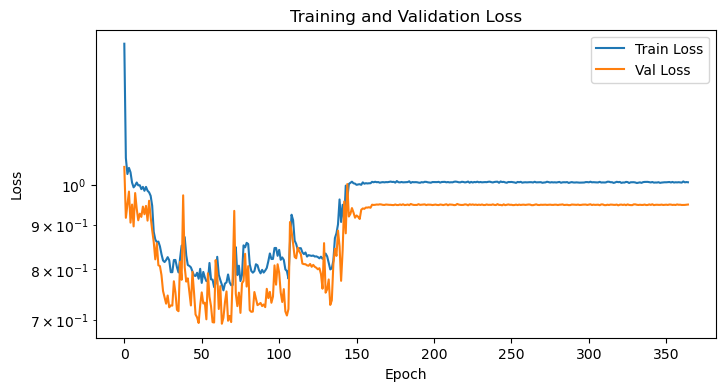

In [27]:
#Plot the training history
plt.figure(figsize=(8,4))
plt.plot(history['train'], label='Train Loss')
plt.plot(history['val'], label='Val Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [28]:
import plotly.graph_objects as go
import os

# Check columns
print("Columns in df:", df.columns.tolist())

fig = go.Figure()

if 'Re' not in df.columns:
    raise RuntimeError("Your DataFrame must contain column 'Re' for grouping.")

# Loop through unique Re values
for re in sorted(df['Re'].unique()):
    sub = df[df['Re'] == re].sort_values('Eta')

    fig.add_trace(go.Scatter(
        x=sub['Eta'],
        y=sub['Pi_val'],
        mode='lines',
        name=f'Pi true (Re={re})'
    ))

fig.update_layout(
    title='Pi (true) vs Eta for different Re',
    xaxis_title='Eta',
    yaxis_title='Pi value',
    template='plotly_white'
)

# Save interactive HTML
out_html = os.path.join(OUT_DIR, "Pi_values_plotly.html")
fig.write_html(out_html)
fig.show()

print("Saved interactive Plotly plot →", out_html)


Columns in df: ['Re', 'Eta', 'Pi_val', 'combo', 'p_Pi_val', 'err_Pi2', 'Re_str']


Saved interactive Plotly plot → pinn_fg_long_out_3\Pi_values_plotly.html


In [31]:
import os
import plotly.graph_objects as go

# --- checks ---
needed = ['p_Pi_val', 'Pi_val']
for c in needed:
    if c not in df.columns:
        raise RuntimeError(f"DataFrame must contain '{c}' column")

# OUT_DIR safe
os.makedirs(OUT_DIR, exist_ok=True)

# If 'Re' missing, create single-group 'all'
if 'Re' not in df.columns:
    df['Re'] = 'all'
    print("No 'Re' column found — using single group label 'all'.")

fig = go.Figure()

# Loop through unique Re values and add traces
for re_val in sorted(df['Re'].unique()):
    sub = df[df['Re'] == re_val].copy()
    # prefer Eta on x-axis if present, otherwise use index
    if 'Eta' in sub.columns:
        sub = sub.sort_values('Eta')
        x = sub['Eta']
        x_label = 'Eta'
    else:
        x = sub.index
        x_label = 'index'

    # Predicted curve
    fig.add_trace(go.Scatter(
        x=x,
        y=sub['p_Pi_val'],
        mode='lines',
        name=f'Pi pred (Re={re_val})'
    ))

    # Optional: also plot true values (uncomment if desired)
    fig.add_trace(go.Scatter(
        x=x,
        y=sub['Pi_val'],
        mode='lines',
        name=f'Pi true (Re={re_val})',
        line=dict(dash='dash')
    ))

fig.update_layout(
    title='Pi true and pred vs Eta (grouped by Re)',
    xaxis_title=x_label,
    yaxis_title='Pi value',
    template='plotly_white',
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

out_html = os.path.join(OUT_DIR, "Pi_pred_vs_true_by_Re.html")
fig.write_html(out_html)
fig.show()
print("Saved interactive Plotly HTML ->", out_html)


Saved interactive Plotly HTML -> pinn_fg_long_out_3\Pi_pred_vs_true_by_Re.html


In [ ]:
#PLOT PLOTLY GRAPH FOR aCTUAL VALUES F1 to F12
import plotly.express as px
import plotly.graph_objects as go
fig = go.Figure()
for k in range(1,7):
    sub = df[df['k']==k].sort_values('Eta')
    ri,m = k_map[int(k)]
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['Cf_val'], mode='markers', name=f'F true k={int(k)} Ri={ri} M={m}'))
    fig.add_trace(go.Scatter(x=sub['Eta'], y=sub['p_Cf_val'], mode='lines', name=f'F pred k={int(k)} Ri={ri} M={m}'))
    
fig.update_layout(title='F and G values vs Eta for different k, Ri, M', xaxis_title='Eta', yaxis_title='Values')
fig.write_html(os.path.join(OUT_DIR, "F_F-Pred_values_plotly.html"))
fig.show()